# Pivot Table และการรวมข้อมูลใน Excel ด้วย OpenPyxl และ Pandas - ตอนที่ 5

**คำอธิบาย:** สร้างและจัดการ Pivot Table ด้วย Python กับ Openpyxl และ Pandas

**หัวข้อที่ครอบคลุม:**
- แนะนำ Pivot Table และความสำคัญ
- ตั้งค่า Python environment และติดตั้งไลบรารี
- โหลดข้อมูลเข้า Pandas DataFrame จากไฟล์ Excel
- ทำความเข้าใจโครงสร้าง Pivot Table
- สร้าง Pivot Table พื้นฐานด้วย Pandas
- จัดกลุ่มข้อมูลและใช้ฟังก์ชันรวม (aggregation)
- ส่งผลลัพธ์ Pivot Table กลับไป Excel ด้วย Openpyxl
- แปลงวันที่เป็นเดือนและสร้าง Pivot Table

In [ ]:
# 📦 ติดตั้ง packages ที่จำเป็น (ข้ามถ้าติดตั้งแล้ว)
try:
    import openpyxl
    import pandas
    import numpy
    print("✅ ติดตั้ง packages ทั้งหมดแล้ว")
except ImportError:
    %pip install openpyxl pandas numpy

✅ Packages already installed.


In [ ]:
# 📚 นำเข้าไลบรารี
# openpyxl — เขียนผลลัพธ์ Pivot Table ลง Excel และจัดรูปแบบ
# dataframe_to_rows — แปลง pandas DataFrame เป็นรูปแบบแถวของ openpyxl
# pandas — สร้าง Pivot Table และจัดการข้อมูล
import openpyxl
from openpyxl import Workbook, load_workbook
from openpyxl.utils.dataframe import dataframe_to_rows
import pandas as pd

## 1. สร้างข้อมูลตัวอย่าง

In [ ]:
# 📝 สร้างข้อมูลตัวอย่าง — 100 แถวของข้อมูลคำสั่งซื้อแบบ Superstore
# np.random.seed(42) ทำให้ข้อมูลสุ่มเหมือนกันทุกครั้ง
# pd.date_range สร้างลำดับวันที่
# np.random.choice สุ่มเลือกค่าจากรายการ
import numpy as np
np.random.seed(42)

n = 100
data = {
    'Order Date': pd.date_range('2024-01-01', periods=n, freq='3D'),
    'Category': np.random.choice(['Technology', 'Furniture', 'Office Supplies'], n),
    'Sub-Category': np.random.choice(['Phones', 'Chairs', 'Paper', 'Laptops', 'Tables', 'Binders'], n),
    'Segment': np.random.choice(['Consumer', 'Corporate', 'Home Office'], n),
    'State': np.random.choice(['California', 'Texas', 'New York', 'Florida', 'Illinois'], n),
    'Sales': np.round(np.random.uniform(50, 3000, n), 2),
    'Quantity': np.random.randint(1, 15, n),
    'Profit': np.round(np.random.uniform(-200, 1000, n), 2),
}

df = pd.DataFrame(data)
df.to_excel('Superstore_Pivot.xlsx', index=False, sheet_name='Data')
print(f"✅ สร้างข้อมูลตัวอย่าง: {df.shape}")
df.head()

✅ Created sample data: (100, 8)


,Order Date,Category,Sub-Category,Segment,State,Sales,Quantity,Profit
0,2024-01-01,Office Supplies,Laptops,Corporate,Florida,1398.93,7,-66.56
1,2024-01-04,Technology,Paper,Corporate,California,2533.97,9,391.15
2,2024-01-07,Office Supplies,Paper,Home Office,Florida,623.42,3,-186.38
3,2024-01-10,Office Supplies,Phones,Corporate,California,1263.49,9,362.39
4,2024-01-13,Technology,Paper,Home Office,Illinois,2113.56,14,-132.44


## 2. อ่านข้อมูล

In [ ]:
# 📖 อ่านไฟล์ Excel กลับเข้า DataFrame
# pd.read_excel() โหลดไฟล์ .xlsx เข้า pandas DataFrame
df = pd.read_excel('Superstore_Pivot.xlsx')
print(f"ขนาดข้อมูล: {df.shape}")
print(f"\nคอลัมน์: {df.columns.tolist()}")
df.head(2)

Shape: (100, 8)

Columns: ['Order Date', 'Category', 'Sub-Category', 'Segment', 'State', 'Sales', 'Quantity', 'Profit']


,Order Date,Category,Sub-Category,Segment,State,Sales,Quantity,Profit
0,2024-01-01,Office Supplies,Laptops,Corporate,Florida,1398.93,7,-66.56
1,2024-01-04,Technology,Paper,Corporate,California,2533.97,9,391.15


## 3. สร้าง Pivot Table พื้นฐาน

In [ ]:
# 📊 PIVOT TABLE พื้นฐาน — สรุปข้อมูลตาม Category และ Segment
# pd.pivot_table() คือคำสั่ง Python ที่เทียบเท่า Pivot Table ใน Excel!
# index = ป้ายแถว (Category)
# columns = หัวคอลัมน์ (Segment)
# values = ค่าที่จะรวม (Sales, Quantity, Profit)
# aggfunc = วิธีรวม ('sum', 'mean', 'count' ฯลฯ)
pivot_table = pd.pivot_table(
    df,
    values=['Sales', 'Quantity', 'Profit'],
    index=['Category'],
    columns=['Segment'],
    aggfunc={
        'Sales': 'sum',
        'Quantity': 'sum',
        'Profit': 'sum'
    }
)

print("Pivot Table: Category x Segment")
pivot_table

Pivot Table: Category x Segment


Profit                       Quantity                        \
Segment         Consumer Corporate Home Office Consumer Corporate Home Office   
Category                                                                        
Furniture        6036.69   2866.59     6160.80       93        75         105   
Office Supplies  4122.01   6365.86     7647.80       55        84         103   
Technology       5867.95   4322.04     3725.63       81       111          71   

                    Sales                        
Segment          Consumer Corporate Home Office  
Category                                         
Furniture        19374.03  11129.32    16814.04  
Office Supplies  12986.31  12518.89    18344.32  
Technology       19618.96  23007.25    15069.43

## 4. Pivot Table แบบหลาย Aggregation

In [ ]:
# 📊 หลาย AGGREGATION — ใช้หลายฟังก์ชันกับคอลัมน์เดียวกัน
# aggfunc เป็น list ได้: ['sum', 'mean', 'count', 'max', 'min']
# Multi-level index: Category → Sub-Category ให้การแยกย่อยแบบลำดับชั้น
pivot_multi = pd.pivot_table(
    df,
    values='Sales',
    index=['Category', 'Sub-Category'],
    aggfunc=['sum', 'mean', 'count', 'max', 'min']
)

print("Pivot Table แบบหลาย Aggregation:")
pivot_multi

Multi-aggregation Pivot Table:


sum         mean count      max      min
                                 Sales        Sales Sales    Sales    Sales
Category        Sub-Category                                               
Furniture       Binders        7206.16  1441.232000     5  2470.26   164.94
                Chairs          320.81   320.810000     1   320.81   320.81
                Laptops       13145.12  1460.568889     9  2470.89   429.08
                Paper          8674.55  1239.221429     7  2910.13   165.60
                Phones        10526.37  1503.767143     7  2094.03  1042.83
                Tables         7444.38  1063.482857     7  2665.71    95.15
Office Supplies Binders        6657.48  2219.160000     3  2608.24  1988.48
                Chairs         9004.67  1286.381429     7  2834.48   171.15
                Laptops        5488.58  1372.145000     4  2301.93   819.05
                Paper          4139.48   827.896000     5  1335.24   426.68
                Phones        12004.03  1333.781111     9  2203.62   441.60
                Tables         6555.28  2185.093333     3  2430.39  1966.83
Technology      Binders       13125.85  1640.731250     8  2904.36   753.86
                Chairs         2037.56  1018.780000     2  1748.98   288.58
                Laptops        9487.82  1897.564000     5  2607.99  1071.60
                Paper         16156.63  1795.181111     9  2849.98   458.14
                Phones         8025.12  1605.024000     5  2807.11   100.63
                Tables         8862.66  2215.665000     4  2939.56  1513.31

## 5. Pivot Table ตามรัฐ

In [ ]:
# 📊 PIVOT ตามรัฐ — พร้อมแถวและคอลัมน์ Grand Total
# fill_value=0 แทน NaN ด้วย 0 (ไม่มีข้อมูลสำหรับชุดนั้น)
# margins=True เพิ่มแถวและคอลัมน์ "Grand Total"
# margins_name ตั้งป้ายชื่อสำหรับ Total
pivot_state = pd.pivot_table(
    df,
    values=['Sales', 'Profit'],
    index='State',
    columns='Category',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='Grand Total'
)

print("ยอดขายและกำไร ตามรัฐและหมวดหมู่:")
pivot_state

Sales & Profit by State and Category:


Profit                                            Sales  \
Category    Furniture Office Supplies Technology Grand Total Furniture   
State                                                                    
California    4679.29         3377.66    1310.08     9367.03  13662.51   
Florida       2691.39         4592.95    1692.38     8976.72   5530.18   
Illinois      1878.32         3387.43    3981.69     9247.44   5657.06   
New York      2682.89         3654.62    3503.87     9841.38   8258.32   
Texas         3132.19         3123.01    3427.60     9682.80  14209.32   
Grand Total  15064.08        18135.67   13915.62    47115.37  47317.39   

                                                    
Category    Office Supplies Technology Grand Total  
State                                               
California         11103.05   10741.26    35506.82  
Florida            11510.22   10332.09    27372.49  
Illinois            5976.97   11014.51    22648.54  
New York            7714.57    9369.53    25342.42  
Texas               7544.71   16238.25    37992.28  
Grand Total        43849.52   57695.64   148862.55

## 6. แปลงวันที่เป็นเดือนและสร้าง Pivot Table

In [ ]:
# 📅 ดึงเดือนจากวันที่ — มีประโยชน์สำหรับรายงานรายเดือน
# .dt.month_name() = "January", "February" ฯลฯ
# .dt.month = 1, 2, 3... (สำหรับเรียงลำดับ)
# sort_values() เรียงตามยอดขายรวมจากมากไปน้อย
df['Month'] = df['Order Date'].dt.month_name()
df['Month_Num'] = df['Order Date'].dt.month

pivot_monthly = pd.pivot_table(
    df,
    values=['Sales', 'Profit', 'Quantity'],
    index='Month',
    aggfunc='sum'
).sort_values('Sales', ascending=False)

print("Pivot Table รายเดือน:")
pivot_monthly

Monthly Pivot Table:


,Profit,Quantity,Sales
Month,,,
June,5736.71,91,22525.77
July,5171.75,93,16988.67
September,4136.27,63,16779.50
May,5221.18,84,15813.79
January,2980.72,77,15298.97
March,5758.75,84,15061.05
August,6387.74,72,13546.83
October,3875.55,72,12310.09
February,3758.80,69,11612.37


In [ ]:
# 📅 ยอดขายรายเดือนตามหมวดหมู่ — เรียงตามลำดับเดือนจริง
# .reindex(month_order) เรียงแถวตามลำดับเดือนจริง (ม.ค., ก.พ., มี.ค....)
# ถ้าไม่ใช้ reindex เดือนจะเรียงตามตัวอักษร
pivot_month_cat = pd.pivot_table(
    df,
    values='Sales',
    index='Month',
    columns='Category',
    aggfunc='sum',
    fill_value=0
)

# เรียงตามลำดับเดือนจริง (ไม่ใช่ตัวอักษร)
month_order = df.drop_duplicates('Month').sort_values('Month_Num')['Month'].tolist()
pivot_month_cat = pivot_month_cat.reindex(month_order)

print("ยอดขายรายเดือนตามหมวดหมู่:")
pivot_month_cat

Monthly Sales by Category:


Category,Furniture,Office Supplies,Technology
Month,,,
January,2910.13,7283.17,5105.67
February,6959.93,2118.93,2533.51
March,1107.14,5527.34,8426.57
April,1243.31,4642.01,3040.19
May,3772.27,6699.15,5342.37
June,6008.56,9236.87,7280.34
July,13423.11,858.19,2707.37
August,7966.79,4066.73,1513.31
September,3926.15,1282.94,11570.41


## 7. GroupBy เป็นทางเลือก

In [ ]:
# 🔄 GROUPBY — เป็นทางเลือกแทน Pivot Table สำหรับการรวมข้อมูล
# .groupby('คอลัมน์').agg({...}) จัดกลุ่มแถวแล้วใช้ฟังก์ชัน
# สามารถใช้หลายฟังก์ชันกับคอลัมน์ต่างกันได้
# .round(2) จำกัดทศนิยม 2 ตำแหน่ง
grouped = df.groupby('Category').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean'],
    'Quantity': 'sum'
}).round(2)

print("สรุป GroupBy:")
grouped

GroupBy Summary:


Sales                   Profit         Quantity
                      sum     mean count       sum    mean      sum
Category                                                           
Furniture        47317.39  1314.37    36  15064.08  418.45      273
Office Supplies  43849.52  1414.50    31  18135.67  585.02      242
Technology       57695.64  1748.35    33  13915.62  421.69      263

## 8. ส่งออก Pivot Table ไป Excel ด้วย Openpyxl

In [ ]:
# 📤 ส่งออก Pivot Table ทั้งหมดไปไฟล์ Excel เดียว
# pd.ExcelWriter กับ engine='openpyxl' สร้างไฟล์ Excel หลาย sheet
# แต่ละ .to_excel() เขียน Pivot Table หนึ่งตัวไป sheet แยก
output_file = 'Pivot_Table_Report.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Raw Data', index=False)
    pivot_table.to_excel(writer, sheet_name='Category x Segment')
    pivot_multi.to_excel(writer, sheet_name='Multi-Aggregation')
    pivot_state.to_excel(writer, sheet_name='State Summary')
    pivot_monthly.to_excel(writer, sheet_name='Monthly Summary')
    pivot_month_cat.to_excel(writer, sheet_name='Monthly by Category')

print(f"✅ บันทึกรายงานไปที่: {output_file}")

✅ Report saved to: Pivot_Table_Report.xlsx


## 9. เพิ่มการจัดรูปแบบ Pivot Table ด้วย Openpyxl

In [ ]:
# 🎨 เพิ่มการจัดรูปแบบ — ทำให้รายงานดูเป็นมืออาชีพ
# Font, Alignment, PatternFill = รูปแบบตัวอักษร, ตำแหน่ง, สีเซลล์
# Border, Side = เส้นขอบเซลล์ (เส้นบางรอบเซลล์)
# number_format = '#,##0.00' จัดรูปแบบตัวเลขมีลูกน้ำและทศนิยม 2 ตำแหน่ง
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side

wb = load_workbook(output_file)
ws = wb['Monthly Summary']

# จัดรูปแบบหัวตาราง — พื้นหลังสีน้ำเงิน, ตัวอักษรหนาสีขาว, กลาง
header_fill = PatternFill(start_color='4472C4', end_color='4472C4', fill_type='solid')
header_font = Font(color='FFFFFF', bold=True)
thin_border = Border(
    left=Side(style='thin'),
    right=Side(style='thin'),
    top=Side(style='thin'),
    bottom=Side(style='thin')
)

for cell in ws[1]:
    cell.fill = header_fill
    cell.font = header_font
    cell.alignment = Alignment(horizontal='center')
    cell.border = thin_border

# เพิ่มเส้นขอบและจัดรูปแบบตัวเลขให้เซลล์ข้อมูลทั้งหมด
for row in ws.iter_rows(min_row=2, max_row=ws.max_row, max_col=ws.max_column):
    for cell in row:
        cell.border = thin_border
        if isinstance(cell.value, (int, float)):
            cell.number_format = '#,##0.00'

# ปรับความกว้างคอลัมน์อัตโนมัติตามความยาวเนื้อหา
for col in ws.columns:
    max_length = max(len(str(cell.value or '')) for cell in col)
    ws.column_dimensions[col[0].column_letter].width = max_length + 2

wb.save(output_file)
print("✅ จัดรูปแบบเรียบร้อยแล้ว!")
wb.close()

✅ Formatting applied!


## 10. แสดงกราฟอย่างรวดเร็ว

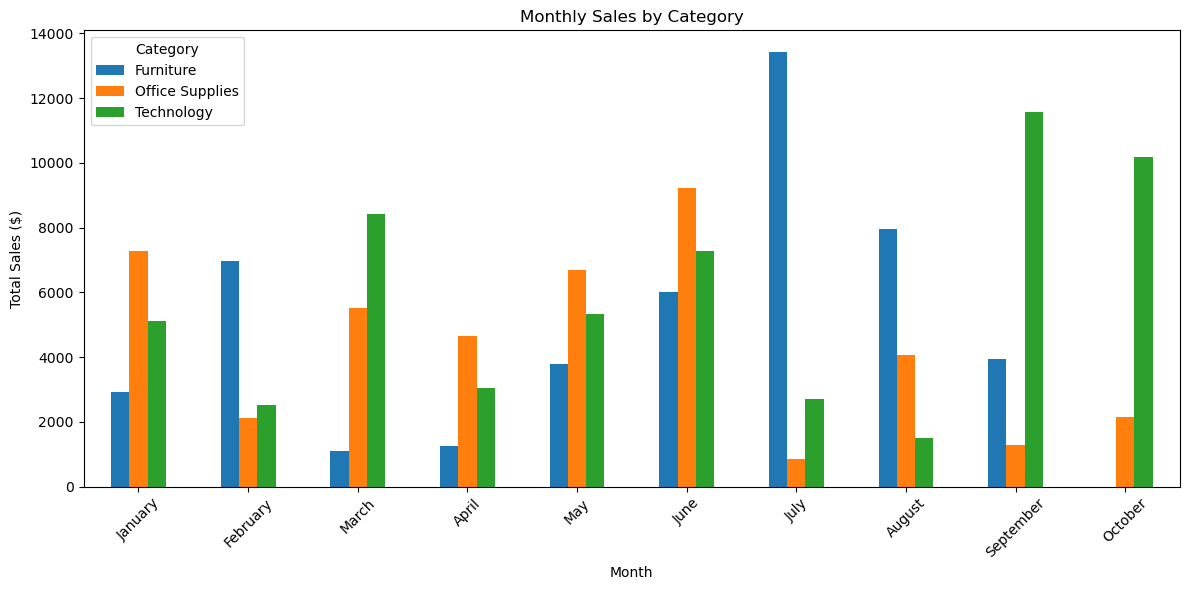

In [ ]:
# 📈 แสดงกราฟอย่างรวดเร็ว — กราฟแท่งยอดขายรายเดือนตามหมวดหมู่
# matplotlib สร้างกราฟได้โดยตรงใน notebook
# .plot(kind='bar') สร้างกราฟแท่งจาก Pivot Table
try:
    import matplotlib.pyplot as plt
    
    pivot_month_cat.plot(kind='bar', figsize=(12, 6))
    plt.title('ยอดขายรายเดือนตามหมวดหมู่')
    plt.ylabel('ยอดขายรวม ($)')
    plt.xlabel('เดือน')
    plt.xticks(rotation=45)
    plt.legend(title='หมวดหมู่')
    plt.tight_layout()
    plt.show()
except ImportError:
    print("💡 ติดตั้ง matplotlib สำหรับสร้างกราฟ: pip install matplotlib")

---

## 🎮 Mini Project: วิเคราะห์ข้อมูล Superstore

สร้าง Pivot Table และกราฟจากข้อมูล Superstore!

> 💡 **คำตอบ:** ดูไฟล์ `answers/06_answers.ipynb`

---

### โจทย์ที่ 1: Pivot Table ยอดขายตาม Region + Category 🟢
ใช้ไฟล์ `superstore.xlsx`:
1. อ่านข้อมูลด้วย `pd.read_excel()`
2. สร้าง `pivot_table` — index=`Region`, columns=`Category`, values=`Sales`, aggfunc=`sum`
3. เพิ่ม `margins=True` เพื่อดูผลรวม
4. แสดง Pivot Table

> 💡 Hint: `pd.pivot_table(df, index=..., columns=..., values=..., aggfunc=..., margins=True)`

In [ ]:
# โจทย์ที่ 1: Pivot Table ยอดขายตาม Region + Category
# เขียนโค้ดของคุณที่นี่ 👇



### โจทย์ที่ 2: Export Pivot Table to Excel + จัดรูปแบบ 🟡
1. สร้าง Pivot Table: index=`Sub-Category`, values=`['Sales','Profit']`, aggfunc=`['sum','mean']`
2. Export ไปยังไฟล์ Excel ใหม่ชื่อ `superstore_analysis.xlsx`
3. จัดรูปแบบ: header สีน้ำเงิน, ตัวเลขมี comma (#,##0.00), ปรับขนาดคอลัมน์
4. บันทึกไฟล์

> 💡 Hint: ใช้ `dataframe_to_rows()` + `Font`, `PatternFill`, `cell.number_format`

In [ ]:
# โจทย์ที่ 2: Export Pivot Table + จัดรูปแบบ
# เขียนโค้ดของคุณที่นี่ 👇



### โจทย์ที่ 3: สร้างกราฟ Bar Chart 🔴
1. สร้าง Pivot Table: ยอดขายรวมตาม `Region`
2. ใช้ `matplotlib` สร้างกราฟแท่ง (bar chart)
3. ตั้งชื่อกราฟ, label แกน x/y ให้สวยงาม
4. ใส่ค่าตัวเลขบนแท่ง

> 💡 Hint: `pivot.plot(kind='bar')` หรือ `plt.bar(x, y)`

In [ ]:
# โจทย์ที่ 3: สร้างกราฟ Bar Chart
# เขียนโค้ดของคุณที่นี่ 👇

